In [15]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('/Users/gayatrishankar/Downloads/emi_prediction_dataset.csv', low_memory=False)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (404800, 27)


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


/var/folders/2g/16kf3jkj1kdc_z0gsnt084500000gn/T/ipykernel_5108/1680104854.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emi_eligibility', palette='Set2')


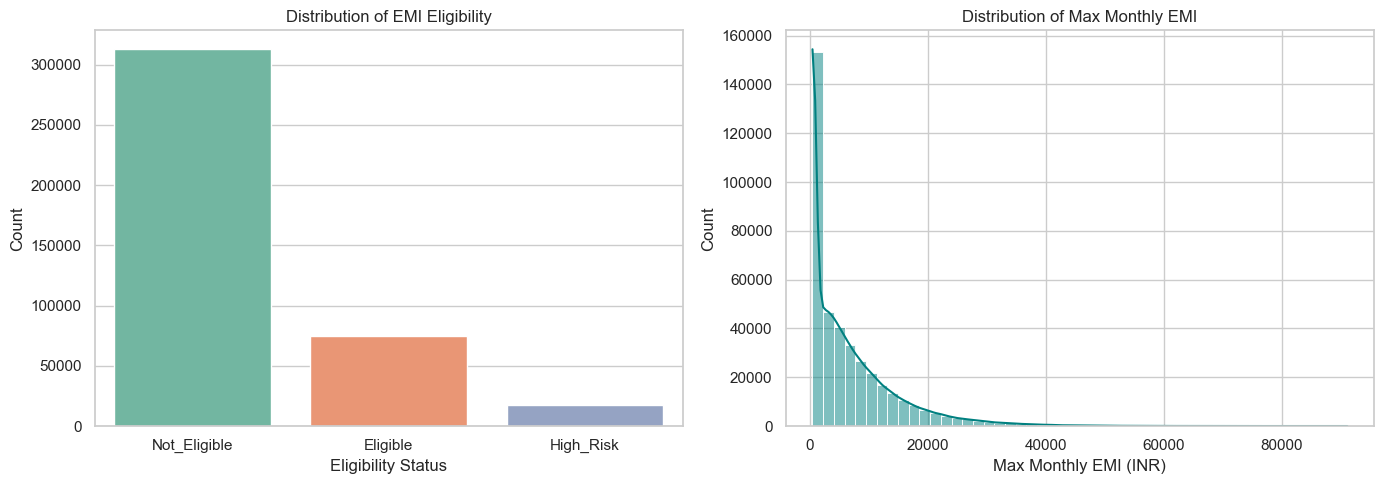

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target Variable Analysis
plt.figure(figsize=(14, 5))

# Classification Target
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='emi_eligibility', palette='Set2')
plt.title('Distribution of EMI Eligibility')
plt.xlabel('Eligibility Status')
plt.ylabel('Count')

# Regression Target (max_monthly_emi)
plt.subplot(1, 2, 2)
sns.histplot(df['max_monthly_emi'], bins=50, kde=True, color='teal')
plt.title('Distribution of Max Monthly EMI')
plt.xlabel('Max Monthly EMI (INR)')

plt.tight_layout()
plt.show()

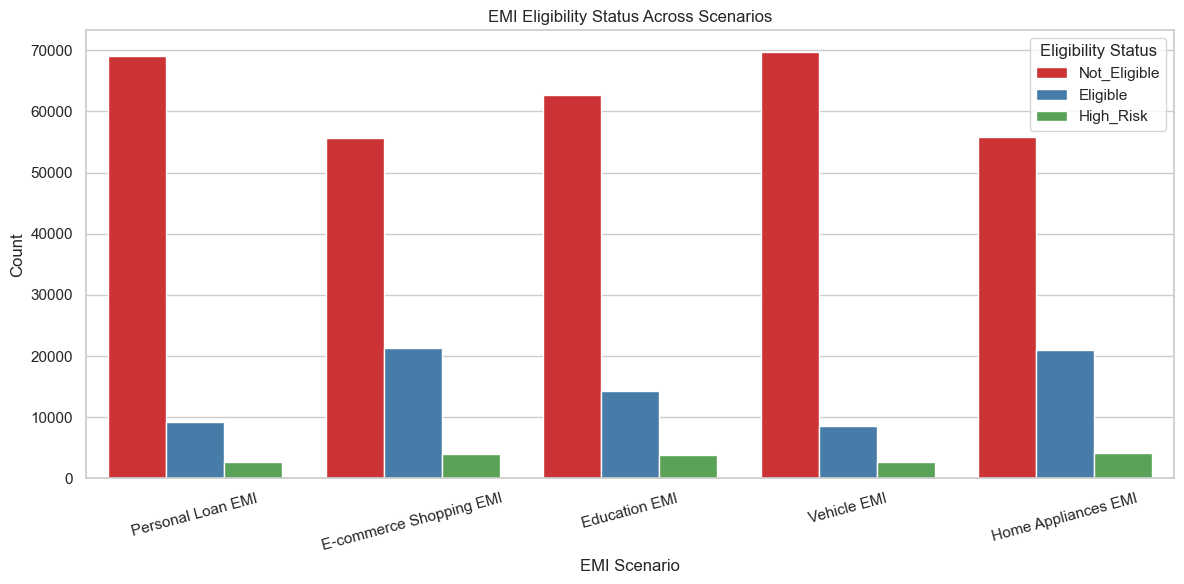

In [19]:
# EDA Scenarios & Risk Analysis
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='emi_scenario', hue='emi_eligibility', palette='Set1')
plt.title('EMI Eligibility Status Across Scenarios')
plt.xlabel('EMI Scenario')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Eligibility Status')
plt.tight_layout()
plt.show()

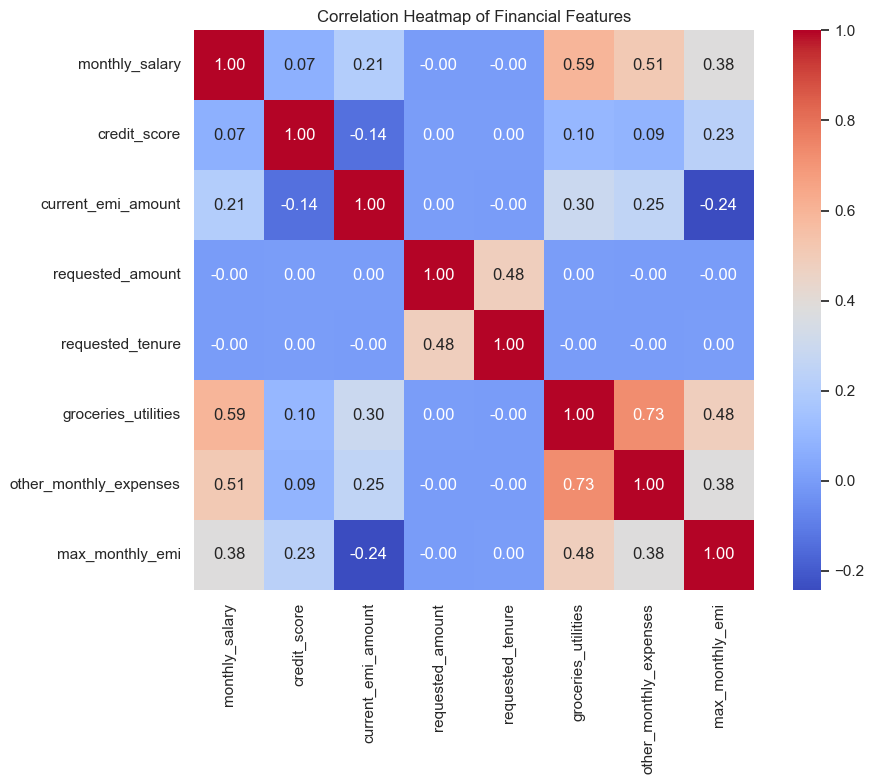

In [23]:
# Correlation Analysis
# Correlation Heatmap of Financial Features 
# Select key numerical columns
num_cols = [
    'monthly_salary', 'credit_score', 'current_emi_amount', 
    'requested_amount', 'requested_tenure', 'groceries_utilities', 
    'other_monthly_expenses', 'max_monthly_emi'
]

# Filter existing columns and force them to numeric data types
available_cols = [c for c in num_cols if c in df.columns]
numeric_df = df[available_cols].apply(pd.to_numeric, errors='coerce')

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Financial Features')
plt.tight_layout()
plt.show()

/var/folders/2g/16kf3jkj1kdc_z0gsnt084500000gn/T/ipykernel_5108/3551235389.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emi_eligibility', y='credit_score', palette='Set3')
/var/folders/2g/16kf3jkj1kdc_z0gsnt084500000gn/T/ipykernel_5108/3551235389.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emi_eligibility', y='monthly_salary', palette='Set3')


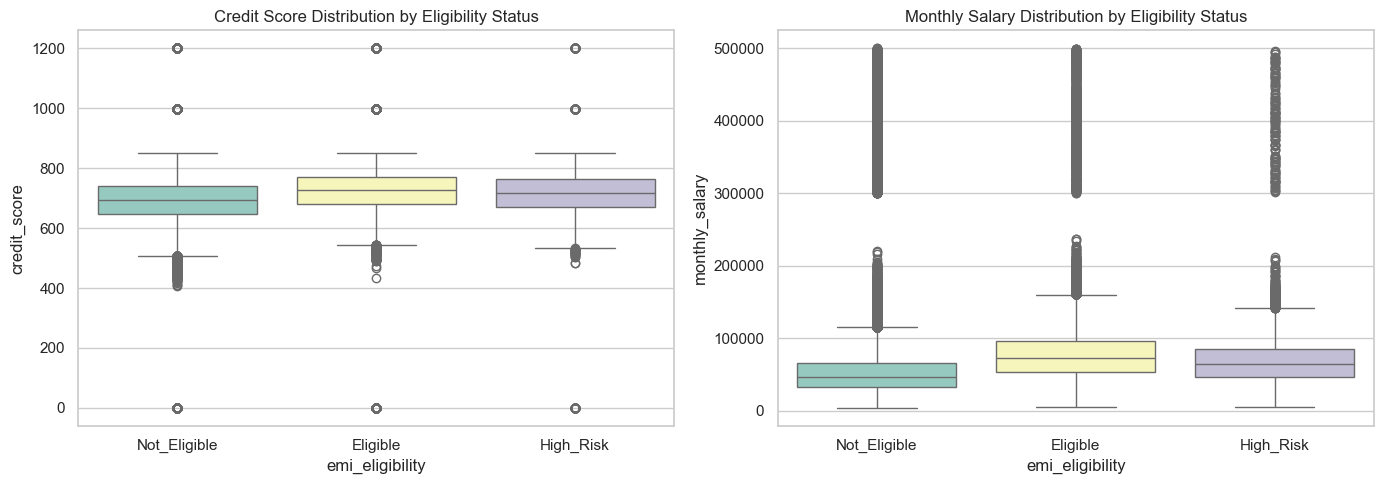

In [24]:
# Credit Score & Salary vs. Risk Factors
# Convert columns to numeric to prevent string errors
df['credit_score'] = pd.to_numeric(df['credit_score'], errors='coerce')
df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')

# Boxplot Analysis for Risk Patterns
plt.figure(figsize=(14, 5))

# 1. Credit Score vs Eligibility
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='emi_eligibility', y='credit_score', palette='Set3')
plt.title('Credit Score Distribution by Eligibility Status')

# 2. Salary vs Eligibility
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='emi_eligibility', y='monthly_salary', palette='Set3')
plt.title('Monthly Salary Distribution by Eligibility Status')

plt.tight_layout()
plt.show()